# Prerequisites

## GPU Setup

In [ ]:
!nvidia-smi
!pip install -q gdown inference-gpu==0.16.3
!pip install -q onnxruntime-gpu==1.18.0 --index-url https://aiinfra.pkgs.visualstudio.com/PublicPackages/_packaging/onnxruntime-cuda-12/pypi/simple/
import os
os.environ["ONNXRUNTIME_EXECUTION_PROVIDERS"] = "[CUDAExecutionProvider]"

Tue Nov 19 10:16:12 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA L4                      Off | 00000000:00:03.0 Off |                    0 |
| N/A   47C    P8              12W /  72W |      1MiB / 23034MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

## Package Installation

In [ ]:
!pip install -q git+https://github.com/roboflow/sports.git
!pip uninstall -y supervision && pip install -q supervision>=0.23.0 inference

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 5.7 MB/s eta 0:00:00
Found existing installation: supervision 0.22.0
Uninstalling supervision-0.22.0:
  Successfully uninstalled supervision-0.22.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inference-gpu 0.16.3 requires docker==6.1.3, but you have docker 7.1.0 which is incompatible.
inference-gpu 0.16.3 requires onnxruntime-gpu<=1.15.1, but you have onnxruntime-gpu 1.18.0 which is incompatible.
inference-gpu 0.16.3 requires opencv-python<=4.8.0.76, but you have opencv-python 4.10.0.84 which is incompatible.
inference-gpu 0.16.3 requires requests<=2.31.0, but you have requests 2.32.3 which is incompatible.
pymc 5.18.0 requires rich>=13.7.1, but you have rich 13.0.1 which is incompati

## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
%cd /content/drive/My Drive/FootballAnalysis/

Mounted at /content/drive/
/content/drive/My Drive/FootballAnalysis


## Imports

In [ ]:
import numpy as np
import torch
from tqdm import tqdm
from transformers import AutoProcessor, SiglipVisionModel
import supervision as sv
from sklearn.cluster import KMeans
from more_itertools import chunked
import umap
from google.colab import userdata
from inference import get_model
import cv2
import pickle
import pandas as pd

## Configuration

In [ ]:
ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
PLAYER_DETECTION_MODEL_ID = "football-players-detection-3zvbc/11" # YOLOv8x
#PLAYER_DETECTION_MODEL_ID = "football-players-detection-3zvbc/1" # YOLOv8s
SIGLIP_MODEL_PATH = 'google/siglip-base-patch16-224'
SOURCE_VIDEO_PATH = "/content/drive/MyDrive/FootballAnalysis/input_videos/121364_0.mp4"
TARGET_VIDEO_PATH = "/content/drive/MyDrive/FootballAnalysis/output_videos/labelled_teams_121364_0.mp4"
SPEED_DISTANCE_VIDEO_PATH = "/content/drive/MyDrive/FootballAnalysis/output_videos/speed_distance_121364_0.mp4"
PLAYER_ID = 2
STRIDE = 30
BALL_ID = 0
GOALKEEPER_ID = 1
REFEREE_ID = 3
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Player Tracking

## Load Player Detection Model


In [ ]:
PLAYER_DETECTION_MODEL = get_model(
    model_id=PLAYER_DETECTION_MODEL_ID,
    api_key=ROBOFLOW_API_KEY
)

## Define Team Classifier

In [ ]:
import joblib

class TeamClassifier:
    def __init__(self, siglip_model_path: str, device: str, batch_size: int = 32):
        self.device = device
        self.batch_size = batch_size
        self.siglip_model_path = siglip_model_path
        self.features_model = SiglipVisionModel.from_pretrained(siglip_model_path).to(device)
        self.processor = AutoProcessor.from_pretrained(siglip_model_path)
        self.reducer = umap.UMAP(n_components=3)
        self.cluster_model = KMeans(n_clusters=2)

    def extract_features(self, crops: list[np.ndarray]) -> np.ndarray:
        crops = [sv.cv2_to_pillow(crop) for crop in crops]
        data = []
        for batch in tqdm(chunked(crops, self.batch_size), desc='Embedding extraction'):
            with torch.no_grad():
                inputs = self.processor(images=batch, return_tensors="pt").to(self.device)
                outputs = self.features_model(**inputs)
                embeddings = torch.mean(outputs.last_hidden_state, dim=1).cpu().numpy()
                data.append(embeddings)
        return np.concatenate(data)

    def fit(self, crops: list[np.ndarray]) -> None:
        data = self.extract_features(crops)
        projections = self.reducer.fit_transform(data)
        self.cluster_model.fit(projections)

    def predict(self, crops: list[np.ndarray]) -> np.ndarray:
        data = self.extract_features(crops)
        projections = self.reducer.transform(data)
        return self.cluster_model.predict(projections)

    def save(self, path: str) -> None:
        joblib.dump({
            "reducer": self.reducer,
            "cluster_model": self.cluster_model,
            "device": self.device,
            "batch_size": self.batch_size,
            "siglip_model_path": self.siglip_model_path
        }, path)

    @classmethod
    def load(cls, path: str) -> "TeamClassifier":
        data = joblib.load(path)
        obj = cls(
            siglip_model_path=data["siglip_model_path"],
            device=data["device"],
            batch_size=data["batch_size"]
        )
        obj.reducer = data["reducer"]
        obj.cluster_model = data["cluster_model"]
        return obj

## Initialize Classifier and Fit on Collected Crops

In [ ]:
import os

file_path = "/content/drive/MyDrive/FootballAnalysis/team_classifier/team_classifier_121364_0.pkl"

if os.path.exists(file_path):
    print("File exists. Loading the saved model...")
    team_classifier = TeamClassifier.load(file_path)
else:
    print("File does not exist. Fitting the model...")
    frame_generator = sv.get_video_frames_generator(
    source_path=SOURCE_VIDEO_PATH, stride=STRIDE
    )

    crops = []

    for frame in tqdm(frame_generator, desc='Collecting Crops'):
        result = PLAYER_DETECTION_MODEL.infer(frame, confidence=0.3)[0]
        detections = sv.Detections.from_inference(result)
        detections = detections.with_nms(threshold=0.5, class_agnostic=True)
        player_detections = detections[detections.class_id == PLAYER_ID]
        player_crops = [sv.crop_image(frame, xyxy) for xyxy in player_detections.xyxy]
        crops.extend(player_crops)

    team_classifier = TeamClassifier(siglip_model_path=SIGLIP_MODEL_PATH, device=DEVICE, batch_size=32)
    team_classifier.fit(crops)
    team_classifier.save(file_path)

File exists. Loading the saved model...


config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.40M [00:00<?, ?B/s]

## Assign Goalkeepers to Teams

In [ ]:
def resolve_goalkeepers_team_id(players: sv.Detections, goalkeepers: sv.Detections) -> np.ndarray:
    goalkeepers_xy = goalkeepers.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
    players_xy = players.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
    team_0_centroid = players_xy[players.class_id == 0].mean(axis=0)
    team_1_centroid = players_xy[players.class_id == 1].mean(axis=0)
    return np.array([0 if np.linalg.norm(goalkeeper_xy - team_0_centroid) < np.linalg.norm(goalkeeper_xy - team_1_centroid) else 1 for goalkeeper_xy in goalkeepers_xy])

## Annotators and Tracker Configuration


In [ ]:
BLUE = "#00BFFF"
PINK = "#FF1493"
YELLOW = "#FFD700"

tracker = sv.ByteTrack()
tracker.reset()

## Process and Label Video


In [ ]:
class CameraMovementEstimator():
    def __init__(self,frame):
        self.minimum_distance = 5

        self.lk_params = dict(
            winSize = (15,15),
            maxLevel = 2,
            criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,10,0.03)
        )

        first_frame_grayscale = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
        mask_features = np.zeros_like(first_frame_grayscale)
        mask_features[:,0:20] = 1
        mask_features[:,900:1050] = 1

        self.features = dict(
            maxCorners = 100,
            qualityLevel = 0.3,
            minDistance =3,
            blockSize = 7,
            mask = mask_features
        )

    def get_camera_movement(self,frames,read_from_stub=False, stub_path=None):
        # Read the stub
        if read_from_stub and stub_path is not None and os.path.exists(stub_path):
            with open(stub_path,'rb') as f:
                return pickle.load(f)

        camera_movement = [[0,0]]*len(frames)

        old_gray = cv2.cvtColor(frames[0],cv2.COLOR_BGR2GRAY)
        old_features = cv2.goodFeaturesToTrack(old_gray,**self.features)

        for frame_num in range(1,len(frames)):
            frame_gray = cv2.cvtColor(frames[frame_num],cv2.COLOR_BGR2GRAY)
            new_features, _,_ = cv2.calcOpticalFlowPyrLK(old_gray,frame_gray,old_features,None,**self.lk_params)

            max_distance = 0
            camera_movement_x, camera_movement_y = 0,0

            for i, (new,old) in enumerate(zip(new_features,old_features)):
                new_features_point = new.ravel()
                old_features_point = old.ravel()

                distance = measure_distance(new_features_point,old_features_point)
                if distance>max_distance:
                    max_distance = distance
                    camera_movement_x,camera_movement_y = measure_xy_distance(old_features_point, new_features_point )

            if max_distance > self.minimum_distance:
                camera_movement[frame_num] = [camera_movement_x,camera_movement_y]
                old_features = cv2.goodFeaturesToTrack(frame_gray,**self.features)

            old_gray = frame_gray.copy()

        if stub_path is not None:
            with open(stub_path,'wb') as f:
                pickle.dump(camera_movement,f)

        return camera_movement

    def draw_camera_movement(self,frames, camera_movement_per_frame):
        output_frames=[]

        for frame_num, frame in enumerate(frames):
            frame= frame.copy()

            overlay = frame.copy()
            cv2.rectangle(overlay,(0,0),(500,100),(255,255,255),-1)
            alpha =0.6
            cv2.addWeighted(overlay,alpha,frame,1-alpha,0,frame)

            x_movement, y_movement = camera_movement_per_frame[frame_num]
            frame = cv2.putText(frame,f"Camera Movement X: {x_movement:.2f}",(10,30), cv2.FONT_HERSHEY_SIMPLEX,1,(0,0,0),3)
            frame = cv2.putText(frame,f"Camera Movement Y: {y_movement:.2f}",(10,60), cv2.FONT_HERSHEY_SIMPLEX,1,(0,0,0),3)

            output_frames.append(frame)

        return output_frames

In [ ]:
class ViewTransformer():
    def __init__(self):
        court_width = 68
        court_length = 23.32

        self.pixel_vertices = np.array([[110, 1035],
                               [265, 275],
                               [910, 260],
                               [1640, 915]])

        self.target_vertices = np.array([
            [0,court_width],
            [0, 0],
            [court_length, 0],
            [court_length, court_width]
        ])

        self.pixel_vertices = self.pixel_vertices.astype(np.float32)
        self.target_vertices = self.target_vertices.astype(np.float32)

        self.persepctive_trasnformer = cv2.getPerspectiveTransform(self.pixel_vertices, self.target_vertices)

    def transform_point(self,point):
        p = (int(point[0]),int(point[1]))
        is_inside = cv2.pointPolygonTest(self.pixel_vertices,p,False) >= 0
        if not is_inside:
            return None

        reshaped_point = point.reshape(-1,1,2).astype(np.float32)
        tranform_point = cv2.perspectiveTransform(reshaped_point,self.persepctive_trasnformer)
        return tranform_point.reshape(-1,2)

In [ ]:
class SpeedAndDistance_Estimator():
    def __init__(self):
        self.frame_window=5
        self.frame_rate=24

    def add_speed_and_distance_to_tracks(self,tracks):
        total_distance= {}

        for object, object_tracks in tracks.items():
            if object == "ball" or object == "referees":
                continue
            number_of_frames = len(object_tracks)
            for frame_num in range(0,number_of_frames, self.frame_window):
                last_frame = min(frame_num+self.frame_window,number_of_frames-1 )

                for track_id,_ in object_tracks[frame_num].items():
                    if track_id not in object_tracks[last_frame]:
                        continue

                    start_position = object_tracks[frame_num][track_id].get('position_transformed', None)
                    end_position = object_tracks[last_frame][track_id].get('position_transformed', None)

                    if start_position is None or end_position is None:
                        continue

                    distance_covered = measure_distance(start_position,end_position)
                    time_elapsed = (last_frame-frame_num)/self.frame_rate
                    speed_meteres_per_second = distance_covered/time_elapsed
                    speed_km_per_hour = speed_meteres_per_second*3.6

                    if object not in total_distance:
                        total_distance[object]= {}

                    if track_id not in total_distance[object]:
                        total_distance[object][track_id] = 0

                    total_distance[object][track_id] += distance_covered

                    for frame_num_batch in range(frame_num,last_frame):
                        if track_id not in tracks[object][frame_num_batch]:
                            continue
                        tracks[object][frame_num_batch][track_id]['speed'] = speed_km_per_hour
                        tracks[object][frame_num_batch][track_id]['distance'] = total_distance[object][track_id]

        return total_distance

    def draw_speed_and_distance(self,frames,tracks):
        output_frames = []
        for frame_num, frame in enumerate(frames):
            for object, object_tracks in tracks.items():
                if object == "ball" or object == "referees":
                    continue
                for _, track_info in object_tracks[frame_num].items():
                   if "speed" in track_info:
                       speed = track_info.get('speed',None)
                       distance = track_info.get('distance',None)
                       if speed is None or distance is None:
                           continue

                       bbox = track_info['bbox']
                       position = get_foot_position(bbox)
                       position = list(position)
                       position[1]+=40

                       position = tuple(map(int,position))
                       cv2.putText(frame, f"{speed:.2f} km/h",position,cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,0,0),2)
                       cv2.putText(frame, f"{distance:.2f} m",(position[0],position[1]+20),cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,0,0),2)
            output_frames.append(frame)

        return output_frames

In [ ]:
def measure_distance(p1,p2):
    return ((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)**0.5

def get_center_of_bbox(bbox):
    x1,y1,x2,y2 = bbox
    return int((x1+x2)/2),int((y1+y2)/2)

def get_foot_position(bbox):
    x1,y1,x2,y2 = bbox
    return int((x1+x2)/2),int(y2)

def measure_xy_distance(p1,p2):
    return p1[0]-p2[0],p1[1]-p2[1]

In [ ]:
SOURCE_VIDEO_PATH = "/content/drive/MyDrive/FootballAnalysis/input_videos/121364_0_trimmed.mp4"
TARGET_VIDEO_PATH = "/content/drive/MyDrive/FootballAnalysis/output_videos/labelled_teams_121364_0_trimmed.mp4"
SPEED_DISTANCE_VIDEO_PATH = "/content/drive/MyDrive/FootballAnalysis/output_videos/speed_distance_121364_0_trimmed.mp4"
PLAYER_ID = 2
STRIDE = 30
BALL_ID = 0
GOALKEEPER_ID = 1
REFEREE_ID = 3
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
video_sink = sv.VideoSink(TARGET_VIDEO_PATH, video_info=video_info)
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

### TODO: Don't convert to list

In [ ]:
video_frames = list(frame_generator)

In [ ]:
camera_movement_estimator = CameraMovementEstimator(video_frames[0])
camera_movement_per_frame = camera_movement_estimator.get_camera_movement(video_frames,
                                                                            read_from_stub=False,
                                                                            stub_path='/content/camera_movement_stub.pkl')

In [ ]:
view_transformer = ViewTransformer()

In [ ]:
def interpolate_ball_positions(ball_positions):
    ball_positions = [x.get(1,{}).get('bbox',[]) for x in ball_positions]
    df_ball_positions = pd.DataFrame(ball_positions,columns=['x1','y1','x2','y2'])

    # Interpolate missing values
    df_ball_positions = df_ball_positions.interpolate()
    df_ball_positions = df_ball_positions.bfill()

    ball_positions = [{1: {"bbox":x}} for x in df_ball_positions.to_numpy().tolist()]

    return ball_positions

In [ ]:
def assign_ball_to_player(players,ball_bbox):
    ball_position = get_center_of_bbox(ball_bbox)
    max_player_ball_distance = 70
    miniumum_distance = 99999
    assigned_player=-1

    for player_id, player in players.items():
        player_bbox = player['bbox']

        distance_left = measure_distance((player_bbox[0],player_bbox[-1]),ball_position)
        distance_right = measure_distance((player_bbox[2],player_bbox[-1]),ball_position)
        distance = min(distance_left,distance_right)

        if distance < max_player_ball_distance:
            if distance < miniumum_distance:
                miniumum_distance = distance
                assigned_player = player_id

    return assigned_player

In [ ]:
# Initialize a dictionary to hold total distances for each player track ID
total_distance = {}

tracks = {
    "players": [],
    "referees": [],
    "ball": []
}

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
video_sink = sv.VideoSink(TARGET_VIDEO_PATH, video_info=video_info)
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

for frame_num, frame in enumerate(tqdm(video_frames, total=video_info.total_frames)):
    result = PLAYER_DETECTION_MODEL.infer(frame, confidence=0.3)[0]
    detections = sv.Detections.from_inference(result)

    # Convert GoalKeeper to player object
    for object_ind, class_id in enumerate(detections.class_id):
        if class_id == GOALKEEPER_ID:
            detections.class_id[object_ind] = PLAYER_ID

    detections = tracker.update_with_detections(detections=detections)

    tracks["players"].append({})
    tracks["referees"].append({})
    tracks["ball"].append({})

    for frame_detection in detections:
        bbox = frame_detection[0].tolist()
        cls_id = frame_detection[3]
        track_id = frame_detection[4]

        # Adjusted position calculation (for camera movement)
        camera_movement = camera_movement_per_frame[frame_num]

        if cls_id == PLAYER_ID:
            tracks["players"][frame_num][track_id] = {"bbox": bbox}
            position = get_foot_position(bbox)
            position_adjusted = (position[0] - camera_movement[0], position[1] - camera_movement[1])
            tracks["players"][frame_num][track_id]['position'] = position
            tracks["players"][frame_num][track_id]['position_adjusted'] = position_adjusted

            # Transform adjusted position
            position_transformed = view_transformer.transform_point(np.array(position_adjusted))
            if position_transformed is not None:
                tracks["players"][frame_num][track_id]['position_transformed'] = position_transformed.squeeze().tolist()

        elif cls_id == REFEREE_ID:
            tracks["referees"][frame_num][track_id] = {"bbox": bbox}
            position = get_foot_position(bbox)
            position_adjusted = (position[0] - camera_movement[0], position[1] - camera_movement[1])
            tracks["referees"][frame_num][track_id]['position'] = position
            tracks["referees"][frame_num][track_id]['position_adjusted'] = position_adjusted

            # Transform adjusted position
            position_transformed = view_transformer.transform_point(np.array(position_adjusted))
            if position_transformed is not None:
                tracks["referees"][frame_num][track_id]['position_transformed'] = position_transformed.squeeze().tolist()

        elif cls_id == BALL_ID:
            # Ensure the ball track data is properly initialized with 'position'
            if track_id not in tracks["ball"][frame_num]:
                tracks["ball"][frame_num][1] = {}  # Initialize the ball entry if not already done

            tracks["ball"][frame_num][1]['bbox'] = bbox  # Use 1 as the constant key
            position = get_center_of_bbox(bbox)
            position_adjusted = (position[0] - camera_movement[0], position[1] - camera_movement[1])
            tracks["ball"][frame_num][1]['position'] = position
            tracks["ball"][frame_num][1]['position_adjusted'] = position_adjusted

            # Transform adjusted position
            position_transformed = view_transformer.transform_point(np.array(position_adjusted))
            if position_transformed is not None:
                tracks["ball"][frame_num][1]['position_transformed'] = position_transformed.squeeze().tolist()

    # Classify Players into Teams
    frame_players = tracks["players"][frame_num]
    player_crops = [sv.crop_image(frame, player_data['bbox']) for player_data in frame_players.values()]
    players_class_id = team_classifier.predict(player_crops)

    # Assign team_id to each player
    for idx, (track_id, player_data) in enumerate(frame_players.items()):
        player_data['team_id'] = players_class_id[idx]
        player_data['has_ball'] = False  # Default 'has_ball' to False

  0%|          | 0/250 [00:00<?, ?it/s]
Embedding extraction: 0it [00:00, ?it/s]
Embedding extraction: 1it [00:01,  1.55s/it]
  0%|          | 1/250 [00:13<54:32, 13.14s/it]
Embedding extraction: 0it [00:00, ?it/s]
Embedding extraction: 1it [00:00,  7.98it/s]
  1%|          | 2/250 [00:15<28:18,  6.85s/it]
Embedding extraction: 0it [00:00, ?it/s]
Embedding extraction: 1it [00:00,  7.82it/s]
  1%|          | 3/250 [00:19<22:00,  5.35s/it]
Embedding extraction: 0it [00:00, ?it/s]
Embedding extraction: 1it [00:00,  7.34it/s]
  2%|▏         | 4/250 [00:21<16:55,  4.13s/it]
Embedding extraction: 0it [00:00, ?it/s]
Embedding extraction: 1it [00:00,  8.27it/s]
  2%|▏         | 5/250 [00:23<13:54,  3.41s/it]
Embedding extraction: 0it [00:00, ?it/s]
Embedding extraction: 1it [00:00,  7.82it/s]
  2%|▏         | 6/250 [00:25<12:07,  2.98s/it]
Embedding extraction: 0it [00:00, ?it/s]
Embedding extraction: 1it [00:00,  7.83it/s]
  3%|▎         | 7/250 [00:29<13:09,  3.25s/it]
Embedding extraction: 

In [ ]:
tracks["ball"] = interpolate_ball_positions(tracks["ball"])
speed_and_distance_estimator = SpeedAndDistance_Estimator()
speed_and_distance_estimator.add_speed_and_distance_to_tracks(tracks)

In [ ]:
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

# Initialize the previous assigned player ID
previous_assigned_player_id = None

for frame_num, frame in enumerate(tqdm(video_frames, total=video_info.total_frames)):
    frame_players = tracks["players"][frame_num]
    # Assign ball possession
    frame_ball = tracks["ball"][frame_num]
    assigned_player_id = assign_ball_to_player(frame_players, frame_ball[1]["bbox"])

    if assigned_player_id == -1:
        if frame_num == 0:
            # On the first frame, assign to the first player's track_id
            if frame_players:
                assigned_player_id = list(frame_players.keys())[0]
        else:
            # For other frames, retain the previous assigned player
            assigned_player_id = previous_assigned_player_id

    # Update has_ball for the current frame
    if assigned_player_id in frame_players:
        frame_players[assigned_player_id]['has_ball'] = True

    # Update the previous assigned player ID
    previous_assigned_player_id = assigned_player_id

100%|██████████| 250/250 [00:00<00:00, 24668.31it/s]


In [ ]:
max_speed = 0
max_speed_player = None

# Iterate through each frame and player track in the video frames
for frame_num, frame in enumerate(video_frames):
    # Print the speed for each player in the current frame, if available
    if 'players' in tracks:
        for track_id, track_info in tracks["players"][frame_num].items():
            speed = track_info.get('speed')
            if speed is not None:
                if speed > max_speed:
                    max_speed = speed
                    max_speed_player = track_id

# Print the maximum speed and corresponding player
if max_speed_player is not None:
    print(f"Player {max_speed_player} reached the maximum speed of {max_speed:.2f} km/h across all frames.")
else:
    print("No speed data available for players.")

Player 17 reached the maximum speed of 49.57 km/h across all frames.


# Saving tracks

In [ ]:
import pickle

# Combine all variables into one dictionary
data_to_save = {
    "tracks": tracks,
    "total_distance": total_distance,
}

# Save as a Pickle file
with open('/content/drive/MyDrive/FootballAnalysis/tracks/121364_0.pkl', 'wb') as file:
    pickle.dump(data_to_save, file)

# Loading tracks

In [ ]:
import pickle

# Load the Pickle file
with open('/content/drive/MyDrive/FootballAnalysis/tracks/121364_0.pkl', 'rb') as file:
    data = pickle.load(file)

# Access the variables
tracks = data["tracks"]
total_distance = data["total_distance"]

In [ ]:
import pandas as pd

# Step 1: Collect all unique track IDs across frames
all_track_ids = set()
for frame_players in tracks["players"]:
    all_track_ids.update(frame_players.keys())

# Step 2: Initialize tracking variables
total_frames = len(tracks["players"])
pass_stats = {track_id: {"completed": 0, "failed": 0} for track_id in all_track_ids}
frame_has_ball = {frame_num: None for frame_num in range(total_frames)}

# Step 3: Extract and compute player stats
player_stats = {}

for frame_num, frame_players in enumerate(tracks["players"]):
    for track_id, player_data in frame_players.items():
        if track_id not in player_stats:
            player_stats[track_id] = {
                "distance": total_distance["players"].get(track_id, 0),
                "speeds": [],
                "frames_tracked": 0,
                "has_ball_frames": 0,
                "team_id": player_data.get("team_id"),
            }
        player_stats[track_id]["frames_tracked"] += 1
        if "speed" in player_data:
            player_stats[track_id]["speeds"].append(player_data["speed"])
        if player_data.get("has_ball"):
            player_stats[track_id]["has_ball_frames"] += 1
            frame_has_ball[frame_num] = track_id

# Step 4: Calculate Pass Completion Rate and No. of Passes
previous_has_ball = None
for frame_num in range(total_frames):
    current_has_ball = frame_has_ball[frame_num]
    if previous_has_ball and current_has_ball and previous_has_ball != current_has_ball:
        previous_team = tracks["players"][frame_num - 1].get(previous_has_ball, {}).get("team_id")
        current_team = tracks["players"][frame_num].get(current_has_ball, {}).get("team_id")
        if previous_team == current_team:
            pass_stats[previous_has_ball]["completed"] += 1
        else:
            pass_stats[previous_has_ball]["failed"] += 1
    previous_has_ball = current_has_ball

# Step 5: Create DataFrame
data = []
for track_id in all_track_ids:
    stats = player_stats.get(track_id, {})
    distance = stats.get("distance", 0)
    speeds = stats.get("speeds", [])
    max_speed = max(speeds, default=0)
    avg_speed = sum(speeds) / len(speeds) if speeds else 0
    frames_tracked = stats.get("frames_tracked", 0)
    possession_percentage = stats.get("has_ball_frames", 0) / total_frames * 100
    num_bboxes = frames_tracked
    team_id = stats.get("team_id")
    passes_completed = pass_stats[track_id]["completed"]
    passes_failed = pass_stats[track_id]["failed"]
    no_of_passes = passes_completed + passes_failed
    pass_completion_rate = (
        passes_completed / no_of_passes * 100
        if no_of_passes > 0
        else 0
    )

    data.append([
        track_id, distance, max_speed, avg_speed,
        frames_tracked / total_frames * 100, num_bboxes,
        possession_percentage, no_of_passes, pass_completion_rate, team_id
    ])

columns = [
    "Player ID", "Distance Run", "Max Speed", "Average Speed",
    "Percentage of Frames Tracked", "No. of Bounding Boxes",
    "Possession Percentage", "No. of Passes", "Pass Completion Rate", "Team ID"
]
df = pd.DataFrame(data, columns=columns)

In [ ]:
df

,Player ID,Distance Run,Max Speed,Average Speed,Percentage of Frames Tracked,No. of Bounding Boxes,Possession Percentage,No. of Passes,Pass Completion Rate,Team ID
0,1,28.120664,34.998150,12.209173,100.0,250,39.6,2,100.000000,1
1,2,0.000000,0.000000,0.000000,26.8,67,0.0,0,0.000000,1
2,3,0.000000,0.000000,0.000000,7.6,19,0.0,0,0.000000,0
3,4,22.948279,25.326927,9.671860,84.0,210,0.0,0,0.000000,0
4,5,0.000000,0.000000,0.000000,100.0,250,0.0,0,0.000000,1
5,6,16.607479,45.556081,11.037586,53.6,134,0.0,0,0.000000,1
6,7,22.355864,44.138180,12.688102,99.2,248,0.0,0,0.000000,0
7,8,33.408747,31.011071,11.592433,100.0,250,0.0,0,0.000000,0
8,9,29.671430,35.807722,10.134401,98.8,247,2.0,1,0.000000,1
9,10,14.970461,22.016025,9.652596,99.2,248,0.0,0,0.000000,1



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

The palette list has fewer values (1) than needed (12) and will cycle, which may produce an uninterpretable plot.

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

The palette list has fewer values (1) than needed (17) and will cycle, which may produce an uninterpretable plot.

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

The palette list has fewer values (1) than needed (12) and will cycle, which may produce an uninterpretable plot.

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same

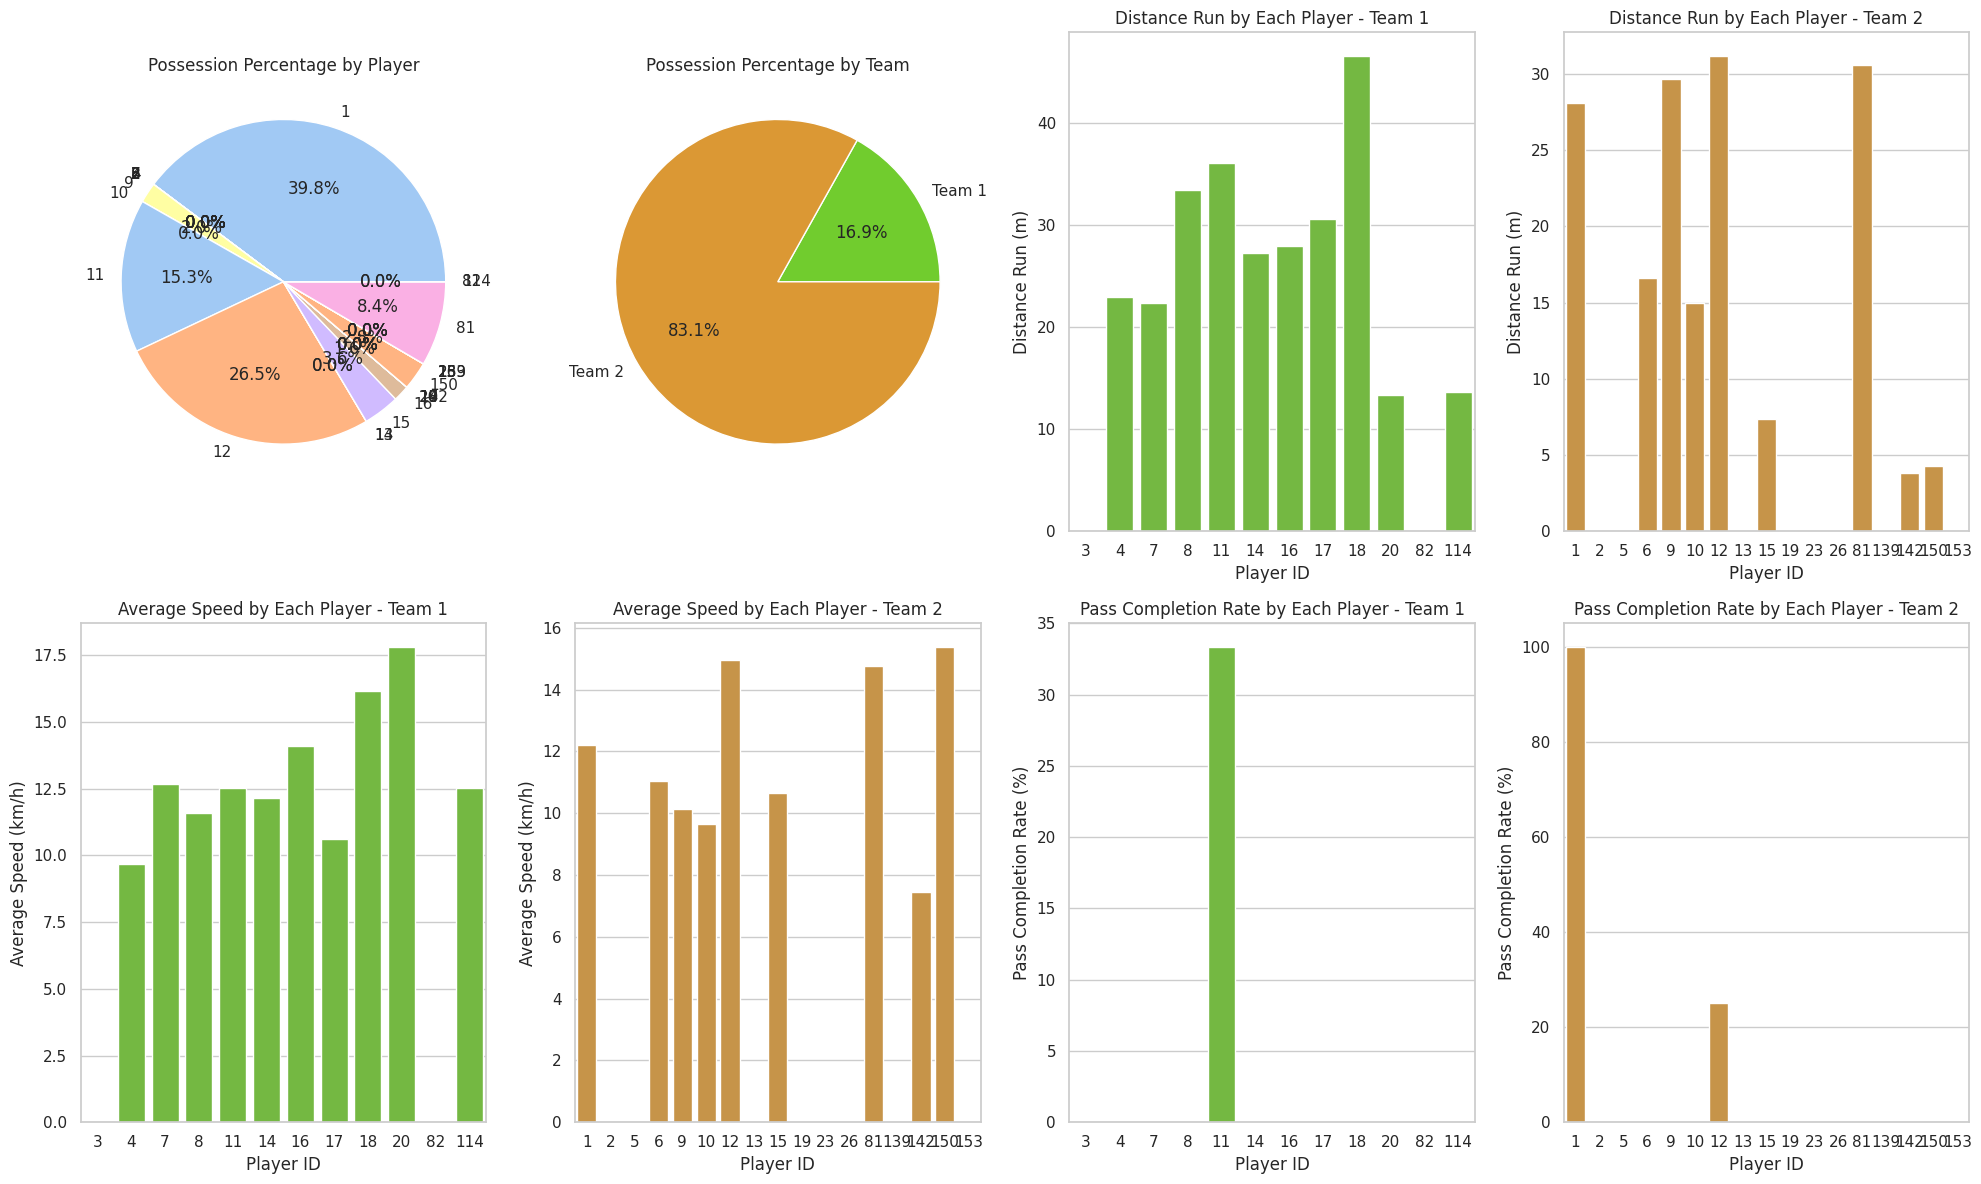

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define team colors
TEAM_1_COLOR = (113, 204, 46)  # Green
TEAM_2_COLOR = (219, 152, 52)  # Blue

# Normalize color values to be in the range 0-1
TEAM_1_COLOR_RGB = (113/255, 204/255, 46/255)  # Green
TEAM_2_COLOR_RGB = (219/255, 152/255, 52/255)  # Blue

# Set Seaborn style
sns.set(style="whitegrid")

# Create a 2x4 grid of subplots (2 rows and 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(20, 12))

# 1. Pie chart of possession percentage according to player
player_possession = df[["Player ID", "Possession Percentage"]]
axes[0, 0].pie(player_possession["Possession Percentage"],
                labels=player_possession["Player ID"],
                autopct='%1.1f%%',
                colors=sns.color_palette("pastel", len(player_possession)))
axes[0, 0].set_title("Possession Percentage by Player")

# 2. Pie chart of possession percentage according to team
team_possession = df.groupby("Team ID")["Possession Percentage"].sum()
team_labels = ["Team 1", "Team 2"]
team_colors = [TEAM_1_COLOR_RGB, TEAM_2_COLOR_RGB]
axes[0, 1].pie(team_possession,
               labels=team_labels,
               autopct='%1.1f%%',
               colors=team_colors)
axes[0, 1].set_title("Possession Percentage by Team")

# 3. Bar graph of distance run for each player from the same team (Team 1)
team_1_df = df[df["Team ID"] == 0]
sns.barplot(x="Player ID", y="Distance Run", data=team_1_df,
            palette=[TEAM_1_COLOR_RGB], ax=axes[0, 2])
axes[0, 2].set_title("Distance Run by Each Player - Team 1")
axes[0, 2].set_xlabel("Player ID")
axes[0, 2].set_ylabel("Distance Run (m)")

# 4. Bar graph of distance run for each player from the same team (Team 2)
team_2_df = df[df["Team ID"] == 1]
sns.barplot(x="Player ID", y="Distance Run", data=team_2_df,
            palette=[TEAM_2_COLOR_RGB], ax=axes[0, 3])
axes[0, 3].set_title("Distance Run by Each Player - Team 2")
axes[0, 3].set_xlabel("Player ID")
axes[0, 3].set_ylabel("Distance Run (m)")

# 5. Bar graph of average speed for each player from the same team (Team 1)
sns.barplot(x="Player ID", y="Average Speed", data=team_1_df,
            palette=[TEAM_1_COLOR_RGB], ax=axes[1, 0])
axes[1, 0].set_title("Average Speed by Each Player - Team 1")
axes[1, 0].set_xlabel("Player ID")
axes[1, 0].set_ylabel("Average Speed (km/h)")

# 6. Bar graph of average speed for each player from the same team (Team 2)
sns.barplot(x="Player ID", y="Average Speed", data=team_2_df,
            palette=[TEAM_2_COLOR_RGB], ax=axes[1, 1])
axes[1, 1].set_title("Average Speed by Each Player - Team 2")
axes[1, 1].set_xlabel("Player ID")
axes[1, 1].set_ylabel("Average Speed (km/h)")

# 7. Bar graph of pass completion rate for each player from the same team (Team 1)
sns.barplot(x="Player ID", y="Pass Completion Rate", data=team_1_df,
            palette=[TEAM_1_COLOR_RGB], ax=axes[1, 2])
axes[1, 2].set_title("Pass Completion Rate by Each Player - Team 1")
axes[1, 2].set_xlabel("Player ID")
axes[1, 2].set_ylabel("Pass Completion Rate (%)")

# 8. Bar graph of pass completion rate for each player from the same team (Team 2)
sns.barplot(x="Player ID", y="Pass Completion Rate", data=team_2_df,
            palette=[TEAM_2_COLOR_RGB], ax=axes[1, 3])
axes[1, 3].set_title("Pass Completion Rate by Each Player - Team 2")
axes[1, 3].set_xlabel("Player ID")
axes[1, 3].set_ylabel("Pass Completion Rate (%)")

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
video_sink = sv.VideoSink(TARGET_VIDEO_PATH, video_info=video_info)
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

team_ball_control = [0]
TEAM_1_COLOR = (113, 204, 46) # Green
TEAM_2_COLOR = (219, 152, 52) # Blue

with video_sink:
    for frame_num, frame in enumerate(tqdm(frame_generator, total=video_info.total_frames)):
        # Add camera movement
        x_movement, y_movement = camera_movement_per_frame[frame_num]
        frame = cv2.putText(frame,f"Camera Movement X: {x_movement:.2f}",(10,30), cv2.FONT_HERSHEY_SIMPLEX,1,(0,0,0),3)
        frame = cv2.putText(frame,f"Camera Movement Y: {y_movement:.2f}",(10,60), cv2.FONT_HERSHEY_SIMPLEX,1,(0,0,0),3)

        # Retrieve the current frame data from tracks
        frame_players = tracks["players"][frame_num]
        frame_ball = tracks["ball"][frame_num]

        assigned_player_id = next((player_id for player_id, data in frame_players.items() if data.get("has_ball")), -1)

        if assigned_player_id == -1:
            team_ball_control.append(team_ball_control[-1])

        # Annotate the players with bounding boxes
        for i, (track_id, player_data) in enumerate(frame_players.items()):
            bbox = player_data['bbox']
            position = player_data['position']

            # Get the speed and distance run (from previous frames)
            distance_covered = player_data.get("distance", None)
            speed_km_per_hour = player_data.get("speed", None)

            # Draw bounding box around the player
            top_left = (int(bbox[0]), int(bbox[1]))
            bottom_right = (int(bbox[2]), int(bbox[3]))


            if track_id == assigned_player_id:
                color = (60, 76, 231) # Red
                team_ball_control.append(players_class_id[i])
            elif player_data["team_id"] == 0:
                color = TEAM_1_COLOR
            else:
                color = TEAM_2_COLOR

            thickness = 2
            cv2.rectangle(frame, top_left, bottom_right, color, thickness)  # Bounding box for player

            if distance_covered is not None or speed_km_per_hour is not None:
              cv2.putText(frame, f"#{track_id}", (int(bbox[0]), int(bbox[3] + 20)),
                          cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)

              cv2.putText(frame, f"{speed_km_per_hour:.2f} km/h", (int(bbox[0]), int(bbox[3] + 40)),
                          cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)

              cv2.putText(frame, f"{distance_covered:.2f} m", (int(bbox[0]), int(bbox[3] + 60)),
                          cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
            else:
              cv2.putText(frame, f"#{track_id}", (int(bbox[0]), int(bbox[3] + 20)),
                          cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)

        # Annotate the ball with an upside-down triangle
        for track_id, ball_data in frame_ball.items():
            bbox = ball_data['bbox']

            # Calculate the center position of the ball from its bounding box
            ball_position = (int((bbox[0] + bbox[2]) / 2), int((bbox[1] + bbox[3]) / 2))

            triangle_points = np.array([
                (ball_position[0], ball_position[1] - 10),  # Move the bottom point up
                (ball_position[0] - 5, ball_position[1] - 20),  # Left point moved up
                (ball_position[0] + 5, ball_position[1] - 20)   # Right point moved up
            ])

            cv2.fillPoly(frame, [triangle_points], color=(15, 196, 241))
            cv2.polylines(frame, [triangle_points], isClosed=True, color=(0, 0, 0), thickness=1)  # Black border


        # Team Ball Control
        team_ball_control_till_frame = np.array(team_ball_control[:frame_num+1])
        # Get the number of time each team had ball control
        team_1_num_frames = team_ball_control_till_frame[team_ball_control_till_frame==0].shape[0]
        team_2_num_frames = team_ball_control_till_frame[team_ball_control_till_frame==1].shape[0]
        team_1 = team_1_num_frames/(team_1_num_frames+team_2_num_frames)
        team_2 = team_2_num_frames/(team_1_num_frames+team_2_num_frames)

        cv2.putText(frame, f"Team 1 Ball Control: {team_1*100:.2f}%",(1400,900), cv2.FONT_HERSHEY_SIMPLEX, 1, TEAM_1_COLOR, 3)
        cv2.putText(frame, f"Team 2 Ball Control: {team_2*100:.2f}%",(1400,950), cv2.FONT_HERSHEY_SIMPLEX, 1, TEAM_2_COLOR, 3)


        # Write the annotated frame to the video sink
        video_sink.write_frame(frame)

  2%|▏         | 6/250 [00:00<00:08, 30.24it/s]

Player with ball: 1
Player with ball: 1
Player with ball: 1
Player with ball: 1
Player with ball: 1
Player with ball: 1
Player with ball: 1
Player with ball: 1
Player with ball: 1
Player with ball: 1


  6%|▋         | 16/250 [00:00<00:05, 42.17it/s]

Player with ball: 1
Player with ball: 1
Player with ball: 1
Player with ball: 1
Player with ball: 1
Player with ball: 1
Player with ball: 1
Player with ball: 1
Player with ball: 1
Player with ball: 1
Player with ball: 1


 11%|█         | 27/250 [00:00<00:04, 46.47it/s]

...

Player with ball: 9
Player with ball: 9
Player with ball: 9
Player with ball: 150
Player with ball: 150
Player with ball: 150
Player with ball: 150
Player with ball: 150
Player with ball: 150
Player with ball: 150
Player with ball: 11


 94%|█████████▎| 234/250 [00:04<00:00, 50.09it/s]

Player with ball: 81
Player with ball: 81
Player with ball: 81
Player with ball: 81
Player with ball: 81
Player with ball: 81
Player with ball: 81
Player with ball: 81
Player with ball: 81
Player with ball: 81
Player with ball: 81


100%|██████████| 250/250 [00:05<00:00, 47.90it/s]

Player with ball: 81
Player with ball: 81
Player with ball: 81
Player with ball: 81
Player with ball: 81
Player with ball: 81
Player with ball: 81
Player with ball: 81
Player with ball: 81
Player with ball: 81
